# Predictive Analysis of EGX30 Stock Trends (2021–2026)
## Data Analysis — Project 3

**Team Members:**
- Mohamed Reda — 24-101232
- Yousef Mohamed — 24-101174
- Taha Ahmed — 24-101520
- Adham Abdo — 24-101016

## Project Overview
This notebook examines the price history of Egypt's top 30 publicly
traded stocks (EGX30) between 2021 and 2026. We analyze market trends,
sector relationships, and key technical indicators to assess whether
short-term stock price movements in the Egyptian market are predictable.

**Section 1 - Importing libraries**

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

**Section 2 - Data preprocessing & cleaning**

In [8]:
import kagglehub

path = kagglehub.dataset_download("mahmoudalrefaey/egx-egyptian-stocks-2021-2026")

print("Path to dataset files:", path)

# Load the top 10 stocks in EGx30
base = path + "/raw"

# Banking Sector
comi = pd.read_csv(base + "/COMI_Commercial Int Bank/COMI.csv")
cieb = pd.read_csv(base + "/CIEB_Credit Agricole Egypt/CIEB.csv")
cana = pd.read_csv(base + "/CANA_Suez Canal Bank/CANA.csv")

# Real Estate Sector
tmgh = pd.read_csv(base + "/TMGH_T M G Holding/TMGH.csv")
phdc = pd.read_csv(base + "/PHDC_Palm Hills Develop/PHDC.csv")
ocdi = pd.read_csv(base + "/OCDI_SODIC/OCDI.csv")

# Telecom Sector
etel = pd.read_csv(base + "/ETEL_Telecom Egypt/ETEL.csv")

# Finance Sector
hrho = pd.read_csv(base + "/HRHO_Hermes Holding Co/HRHO.csv")
ccap = pd.read_csv(base + "/CCAP_Citadel Capital - CS/CCAP.csv")

# Industry Sector
swdy = pd.read_csv(base + "/SWDY_El Sewedy Electric/SWDY.csv")

print("All 10 stocks loaded!")


# Data Cleaning
stocks = {
    'COMI': comi, 'CIEB': cieb, 'CANA': cana,
    'TMGH': tmgh, 'PHDC': phdc, 'OCDI': ocdi,
    'ETEL': etel, 'HRHO': hrho, 'CCAP': ccap, 'SWDY': swdy
}

for name, df in stocks.items():

    # Convert the 'Date' column to a date Python understands
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort rows from oldest to newest date
    df.sort_values('Date', inplace=True)

    # Fill any missing values by copying the last known value forward
    df.ffill(inplace=True)

    # Calculate the daily return for the top 10
    df['dailyReturn'] = df['Close'].pct_change()

    # Save the cleaned version back into our dictionary
    stocks[name] = df

    # Print a quick summary to confirm everything worked
    print(f"{name} — rows: {len(df)}, missing values left: {df.isnull().sum().sum()}")

Using Colab cache for faster access to the 'egx-egyptian-stocks-2021-2026' dataset.
Path to dataset files: /kaggle/input/egx-egyptian-stocks-2021-2026
All 10 stocks loaded!
COMI — rows: 1234, missing values left: 1
CIEB — rows: 1234, missing values left: 1
CANA — rows: 1234, missing values left: 1
TMGH — rows: 1234, missing values left: 1
PHDC — rows: 1234, missing values left: 1
OCDI — rows: 1234, missing values left: 1
ETEL — rows: 1234, missing values left: 1
HRHO — rows: 1234, missing values left: 1
CCAP — rows: 1234, missing values left: 1
SWDY — rows: 1234, missing values left: 1


**Section 3 - Exploratory Data Analysis (EDA)**

PHDC → Average daily return: 0.0020 | Std deviation: 0.0264
HRHO → Average daily return: 0.0013 | Std deviation: 0.0221
COMI → Average daily return: 0.0015 | Std deviation: 0.0193
TMGH → Average daily return: 0.0026 | Std deviation: 0.0276
SWDY → Average daily return: 0.0022 | Std deviation: 0.0286


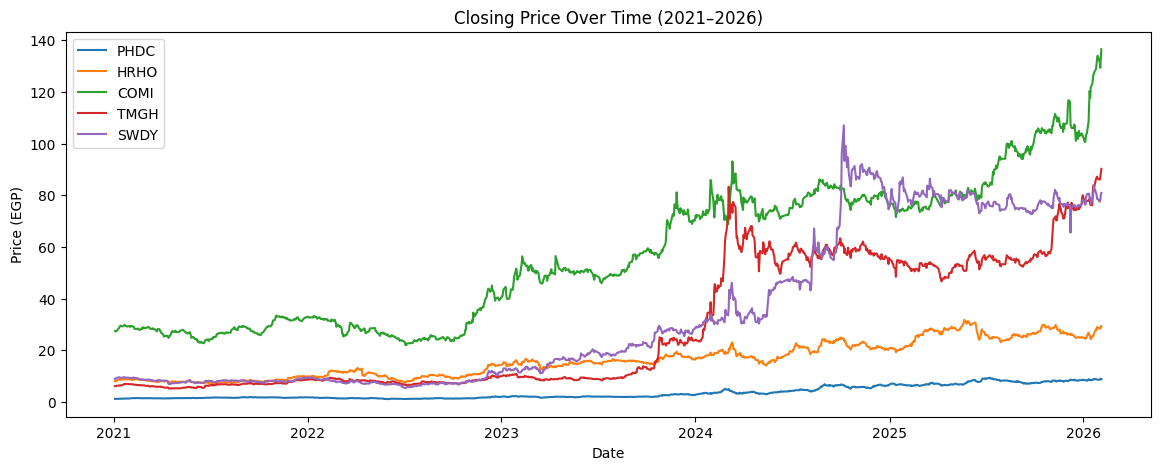

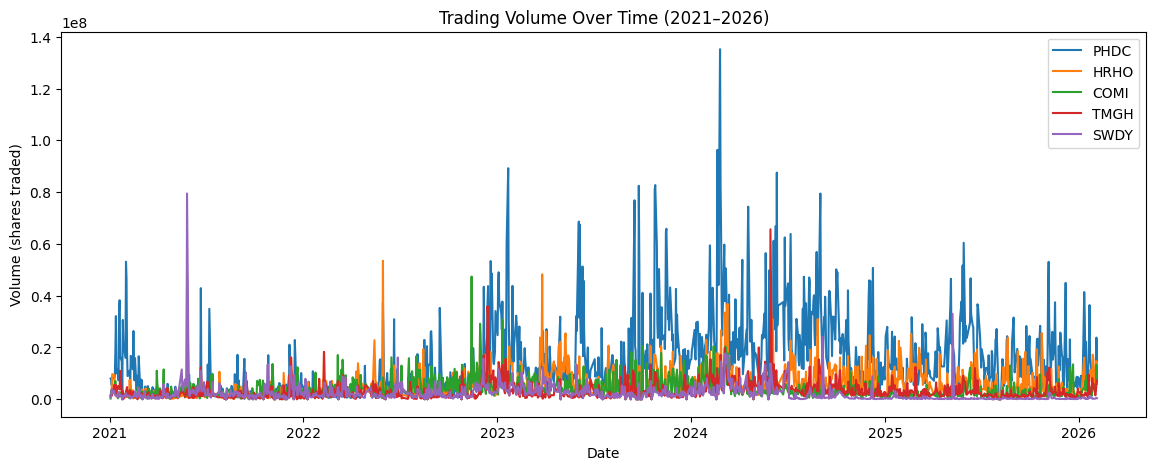

In [9]:
# In this section, we will focus on the top 5 stocks in the EGx30 index
top5 = {
    'PHDC': stocks['PHDC'],  # Real Estate
    'HRHO': stocks['HRHO'],  # Finance
    'COMI': stocks['COMI'],  # Banking
    'TMGH': stocks['TMGH'],  # Real Estate
    'SWDY': stocks['SWDY'],  # Industry
}

# 1- Calculating daily returns summary statistics
for name, df in top5.items():
    mean = df['dailyReturn'].mean()   # average daily return
    std  = df['dailyReturn'].std()    # how much it varies day to day
    print(f"{name} → Average daily return: {mean:.4f} | Std deviation: {std:.4f}")


# 2- Visualizing price trends
plt.figure(figsize=(14, 5))

for name, df in top5.items():
    plt.plot(df['Date'], df['Close'], label=name)

plt.title('Closing Price Over Time (2021–2026)')
plt.xlabel('Date')
plt.ylabel('Price (EGP)')
plt.legend()
plt.show()


# 3- Volume spikes
plt.figure(figsize=(14, 5))

for name, df in top5.items():
    plt.plot(df['Date'], df['Volume'], label=name)

plt.title('Trading Volume Over Time (2021–2026)')
plt.xlabel('Date')
plt.ylabel('Volume (shares traded)')
plt.legend()
plt.show()

###Section 3 Conclusion:

All five stocks show an overall increase in price over time, with some ups and downs. TMGH and SWDY have the highest average daily returns, but they also come with the highest risk. On the other hand, COMI is the most stable stock among the five as it has the lowest standard deviation. Lastly, regarding trading activity, PHDC is the most active

**Section 4 - Correlation Heatmap**

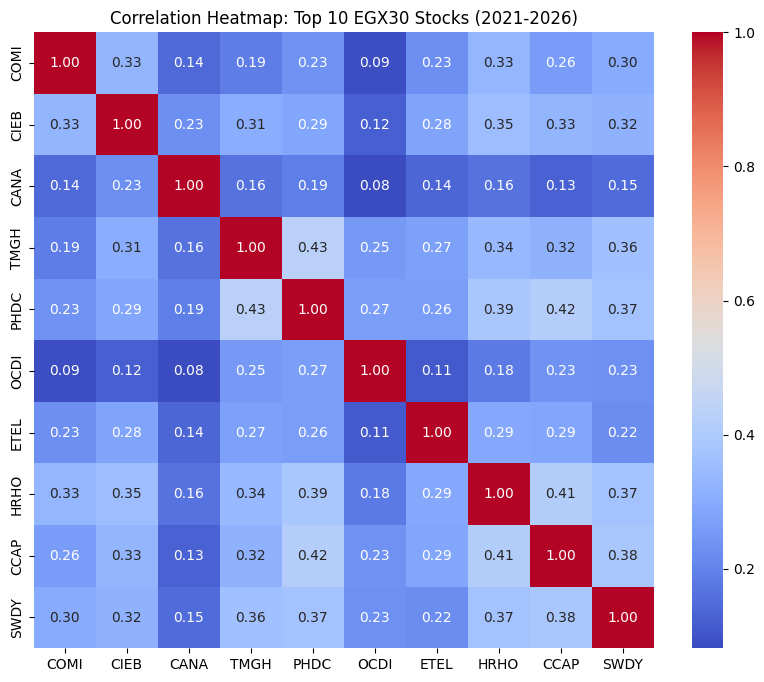

In [10]:
# In this section, we will focus on the top 10 stocks in the EGx30 index

top10 = {
    'COMI': stocks['COMI'], 'CIEB': stocks['CIEB'], 'CANA': stocks['CANA'], # Banking
    'TMGH': stocks['TMGH'], 'PHDC': stocks['PHDC'], 'OCDI': stocks['OCDI'], # Real Estate
    'ETEL': stocks['ETEL'],                                                 # Telecom
    'HRHO': stocks['HRHO'], 'CCAP': stocks['CCAP'],                         # Finance
    'SWDY': stocks['SWDY']                                                  # Industry
}

# We extract daily returns into a single DataFrame for correlation
returnsDF = pd.DataFrame()

for name, df in top10.items():
    returnsDF[name] = df['dailyReturn']

returnsDF.dropna(inplace=True)

# Pearson correlation matrix
corrMatrix = returnsDF.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Top 10 EGX30 Stocks (2021-2026)')
plt.show()

###Section 4 Conclusion:

Most stocks have a weak to moderate positive correlation, meaning they generally move in the same direction but not very strongly. A few pairs like (TMGH and PHDC) in real estate and (HRHO and CCAP) in Finance show stronger relationships, while others (like CANA) are less related to the rest.


**Section 5 - Hypothesis Testing (T-Test)**

H0: The average daily return = 0 (price movement is random)

H1: The average daily return ≠ 0 (there is a real trend)

We use a 1-sample t-test on each of the top 5 stocks,
then a 2-sample t-test comparing Banking vs Real Estate.


In [13]:
# 1-Sample t-test:

print("=== 1-Sample T-Test ===\n")

for name, df in top5.items():
    result = stats.ttest_1samp(df['dailyReturn'].dropna(), 0)
    p = result.pvalue
    if p < 0.05:
      conclusion = "REJECT H0: real trend exists"
    else:
      conclusion = "FAIL TO REJECT H0: looks random"
    print(f"{name} → p-value: {p:.4f} | {conclusion}")


# 2-Sample t-test (Banking vs Real Estate)

print("\n=== 2-Sample T-Test ===\n")

banking = pd.concat([stocks['COMI']['dailyReturn'], stocks['CIEB']['dailyReturn']]).dropna()

realestate = pd.concat([stocks['TMGH']['dailyReturn'], stocks['PHDC']['dailyReturn']]).dropna()

result = stats.ttest_ind(banking, realestate)
p = result.pvalue
if p < 0.05:
    conclusion = "REJECT H0: sectors move differently"
else:
    conclusion = "FAIL TO REJECT H0: sectors move similarly"
print(f"Banking vs Real Estate → p-value: {p:.4f} | {conclusion}")

=== 1-Sample T-Test ===

PHDC → p-value: 0.0094 | REJECT H0: real trend exists
HRHO → p-value: 0.0400 | REJECT H0: real trend exists
COMI → p-value: 0.0069 | REJECT H0: real trend exists
TMGH → p-value: 0.0012 | REJECT H0: real trend exists
SWDY → p-value: 0.0073 | REJECT H0: real trend exists

=== 2-Sample T-Test ===

Banking vs Real Estate → p-value: 0.2784 | FAIL TO REJECT H0: sectors move similarly


###Section 5 Conclusion:

1-Sampled T-Test:

All 5 stocks rejected H0, which means that price movements in EGx30 are not random, there are real trends.

2-Sampled T-Test:

Banking and real estate markets move similarly, which means they tend to react the same way to market events.

**Section 6 - Sector Correlation**

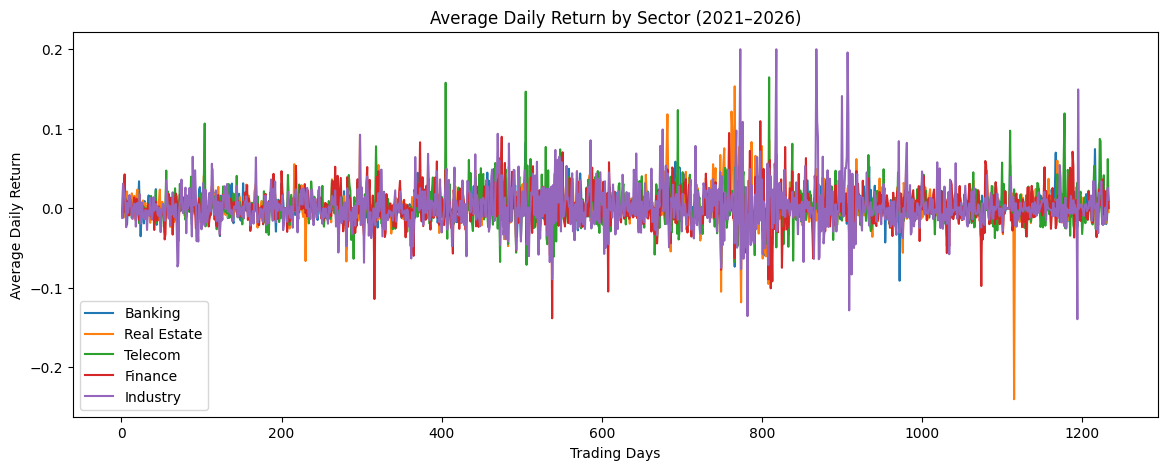

In [14]:
sectorGroups = {
    'Banking':     ['COMI', 'CIEB', 'CANA'],
    'Real Estate': ['TMGH', 'PHDC', 'OCDI'],
    'Telecom':     ['ETEL'],
    'Finance':     ['HRHO', 'CCAP'],
    'Industry':    ['SWDY']
}

plt.figure(figsize=(14, 5))

for sector, sectorStocks in sectorGroups.items():
    avg = pd.concat([stocks[i]['dailyReturn'] for i in sectorStocks], axis=1).mean(axis=1)
    plt.plot(avg.values, label=sector)

plt.title('Average Daily Return by Sector (2021–2026)')
plt.xlabel('Trading Days')
plt.ylabel('Average Daily Return')
plt.legend()
plt.show()

###Section 6 Conclusion

All sectors moved almost identically throughout the 5 years.
They all spike and drop almost at the same time, which suggests that
the Egyptian market clearly reacts to events
as one unit, not sector by sector.